# 과제 1 - SVM 회귀


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_openml
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')


In [10]:
# 데이터 로드
boston = fetch_openml(name='boston', version=1, as_frame=False,n_retries=5)
X, y = boston.data, boston.target

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


URLError: <urlopen error [WinError 10060] 연결된 구성원으로부터 응답이 없어 연결하지 못했거나, 호스트로부터 응답이 없어 연결이 끊어졌습니다>

In [21]:
#서버 연결 불가로 파일을 따로 불러옴
import pandas as pd
boston = pd.read_csv('boston.csv')

X = boston.drop(["MEDV"], axis=1)
y = boston["MEDV"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [41]:
X_train.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
477,15.02340,0.0,18.10,0.0,0.6140,5.304,97.3,2.1007,24.0,666.0,20.2,349.48,24.91
15,0.62739,0.0,8.14,0.0,0.5380,5.834,56.5,4.4986,4.0,307.0,21.0,395.62,8.47
332,0.03466,35.0,6.06,0.0,0.4379,6.031,23.3,6.6407,1.0,304.0,16.9,362.25,7.83
423,7.05042,0.0,18.10,0.0,0.6140,6.103,85.1,2.0218,24.0,666.0,20.2,2.52,23.29
19,0.72580,0.0,8.14,0.0,0.5380,5.727,69.5,3.7965,4.0,307.0,21.0,390.95,11.28


In [22]:
# 모델 생성
svr = LinearSVR(epsilon = 10,random_state = 42)

# 모델 훈련
svr.fit(X_train, y_train)


LinearSVR(epsilon=10, random_state=42)

In [40]:
# 예측
y_pred = svr.predict(X_test)

# 성능 평가
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)


Mean Squared Error: 59.176559261562616
R-squared: 0.19305186898389926


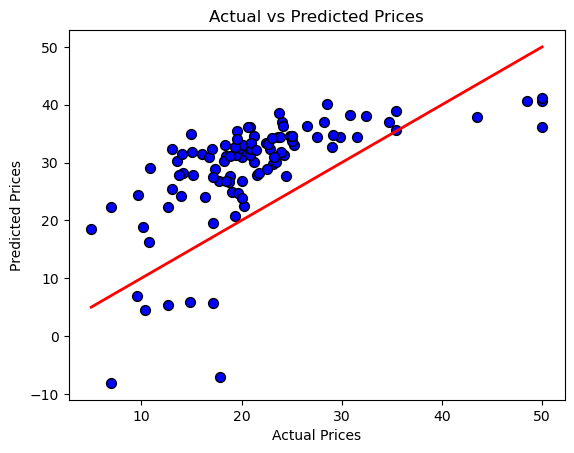

In [24]:
# 일부 feature를 사용하여 2D로 시각화
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', s=50)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()


## 과제 1-1 : epsilon 값을 변경하면서 LinearSVR을 적합한 후, 결과를 확인하고 이유를 분석해주세요!

성능 평가 후 평가지표와 그래프를 사용해서 분석해주세요

In [45]:
#서버 연결 불가 
import pandas as pd
boston = pd.read_csv('boston.csv')

X = boston.drop(["MEDV"], axis=1)
y = boston["MEDV"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 모델 생성
epsilons = [0.01,0.1,0.5,1.0,5.0,10.0,20.0]
MSE = []
R2 =[]

for e in epsilons:
    svr = LinearSVR(epsilon= e, random_state = 42)
    svr.fit(X_train,y_train)
    y_pred = svr.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    MSE.append(mse)
    R2.append(r2)

    print(f'epsilon:{e} , MSE :{mse},R2 :{r2}')


epsilon:0.01 , MSE :161.4887378436338,R2 :-1.2021056446874656
epsilon:0.1 , MSE :160.93337408441545,R2 :-1.194532548969709
epsilon:0.5 , MSE :158.36370637314056,R2 :-1.1594918405740016
epsilon:1.0 , MSE :153.4529022767587,R2 :-1.0925267409330108
epsilon:5.0 , MSE :125.33290026296895,R2 :-0.709074520115307
epsilon:10.0 , MSE :59.176559261562616,R2 :0.19305186898389926
epsilon:20.0 , MSE :99.2455967499594,R2 :-0.3533407451922643


<Figure size 1000x500 with 0 Axes>

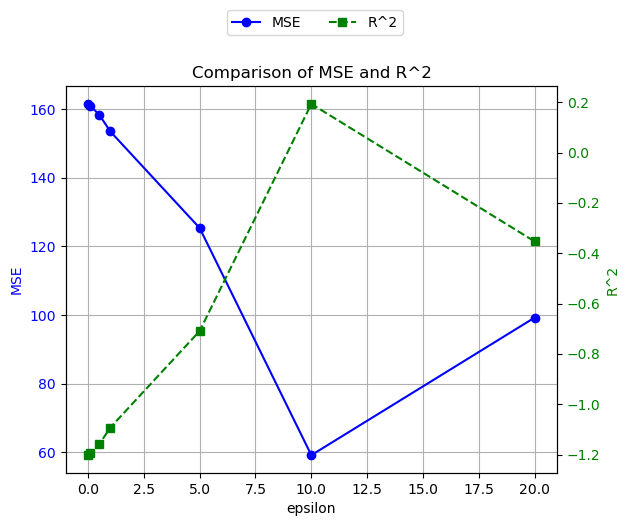

In [59]:
plt.figure(figsize=(10, 5))

# 첫 번째 y축 (MSE)
fig, ax1 = plt.subplots()
ax1.plot(epsilons, MSE, marker='o', label='MSE', color='blue', linestyle='-')
ax1.set_xlabel("epsilon")
ax1.set_ylabel("MSE", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)

# 두 번째 y축 (R^2)
ax2 = ax1.twinx()
ax2.plot(epsilons, R2, marker='s', label='R^2', color='green', linestyle='--')
ax2.set_ylabel("R^2", color='green')
ax2.tick_params(axis='y', labelcolor='green')


plt.title("Comparison of MSE and R^2")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.1), ncol=2)
plt.tight_layout()
plt.show()

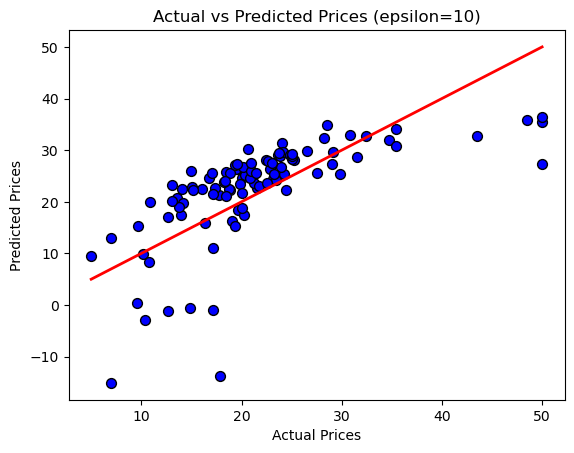

In [24]:
# epsilon=10 시각화 
svr = LinearSVR(epsilon=10, random_state=42)
svr.fit(X_train, y_train)
y_pred = svr.predict(X_test)

plt.scatter(y_test, y_pred_final, color='blue', edgecolor='k', s=50)
plt.plot([min(y_test), max(y_test)],[min(y_test), max(y_test)],color='red',linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices (epsilon=10)')
plt.show()

# Todo

epsilon : SVR에서 epsilon은 모델이 허용하는 오차의 범위. 작은 epsilon 값은 모델이 데이터에 대해 더 정확하게 예측하지만 과적합이 발생할 수 있는 반면, 큰 epsilon 값은 더 큰 오차를 허용하여 모델의 복잡도를 줄이지만, 과도하게 단순해지는 경우에는 예측 성능이 떨어짐.

해당 데이터의 경우 epsilon이 10일 때 MSE가 가장 낮고 R2가 양수로 바뀌면서 모델 성능이 개선된 것을 확인할 수 있었음.


# 과제 1-2 : SVM 분류

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')


In [3]:
# 데이터 로드
iris = load_iris()
X, y = iris.data, iris.target

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 과제 1 - 2 trade-off 파라미터 C 값 설정

아래 수식처럼 C가 동작하는데, C가 작을수록 에러가 생겨도 가중치가 작기에 오버피팅을 막을 수 있음.

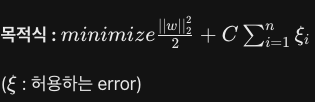


In [15]:
# 다양한 trade-off 파라미터 C 값 설정
C_values = [0.01,0.1,1,5,10,100,1000] # Todo
train_accuracies = []
test_accuracies = []

for C in C_values:
    # 모델 생성
    svc = LinearSVC(C=C,random_state=42)

    # 모델 훈련
    svc.fit(X_train, y_train)

    # 훈련 데이터와 테스트 데이터에 대한 예측
    y_train_pred = svc.predict(X_train)
    y_test_pred = svc.predict(X_test)

    # 정확도 계산
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # 결과 저장
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    # 성능 출력
    print(f"C={C}:")
    print(f"Training Accuracy: {train_acc}")
    print(f"Testing Accuracy: {test_acc}")
    print(f"Classification Report:\n{classification_report(y_test, y_test_pred)}")
    print("-" * 50)


C=0.01:
Training Accuracy: 0.8
Testing Accuracy: 0.8333333333333334
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.44      0.62         9
           2       0.69      1.00      0.81        11

    accuracy                           0.83        30
   macro avg       0.90      0.81      0.81        30
weighted avg       0.89      0.83      0.82        30

--------------------------------------------------
C=0.1:
Training Accuracy: 0.9666666666666667
Testing Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

------

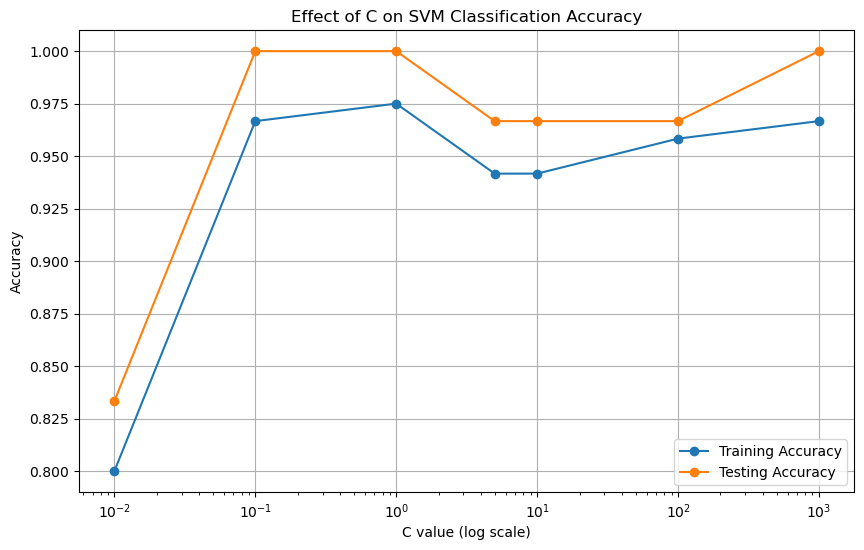

In [16]:
# C 값에 따른 정확도 시각화
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(C_values, test_accuracies, marker='o', label='Testing Accuracy')
plt.xscale('log')
plt.xlabel('C value (log scale)')
plt.ylabel('Accuracy')
plt.title('Effect of C on SVM Classification Accuracy')
plt.legend()
plt.grid(True)
plt.show()


하이퍼파라미터 C : 모델이 훈련 데이터에 대해 얼마나 엄격하게 맞춰지는지를 제어하는 하이퍼파라미터

C 값이 작으면 -> 더 많은 오차 허용하여 모델을 단순하게 만들고 일반화 하지만, 모델의 성능이 좋지 않을 수 있음

C 값이 커지면 -> 훈련 데이터에 더 정확하게 맞추려고하기에 오버피팅의 위험성이 있음. 